In [2505]:
import cv2
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import numpy as np
import pickle
import copy
import optuna

In [2506]:
class WarehouseRobotEnvironment(gym.Env):
    """This class implements the Warehouse Robot environment."""

    def __init__(self, environment_type):
        """This method initializes the environment.
        :param str environment_type: - It can take two values: 1. 'deterministic' 2. 'stochastic'
                                       indicating the type of environment."""
        
        self.environment_type = environment_type   # Inintializing class variable for environment type
        self.grid_size = 6                         # Inintializing grid size
        self.timestep = 0                          # Inintializing time steps
        self.max_timesteps = 100                    # Inintializing max time steps in an episode
        self.action_space = spaces.Discrete(6)     # Inintializing action space
        self.reward = 0                            # Inintializing reward to 0
        self.agent_pos_start = np.asarray([0, 0])                                           # start position
        self.agent_pos = copy.deepcopy(self.agent_pos_start)
        self.goal_pos = np.asarray([5, 5])                                                  # goal position
        self.shelves_pos = np.asarray([[2, 0], [5, 1], [2, 2], [0, 4], [2, 4], [3, 5]])     # Obstacles position(6 shelves)
        self.reserved_spots = [[2, 0], [5, 1], [2, 2], [0, 4], [2, 4], [3, 5], [5,5], [0,0]]
        self.new_positions = []
        while len(self.new_positions)<2:
            rand_pos = [np.random.randint(0, 6), np.random.randint(0, 6)]
            if rand_pos not in self.reserved_spots:
                self.new_positions.append(rand_pos)
        self.b1_box_pos = np.asarray(self.new_positions[0])                                                # box position
        self.b2_box_pos = np.asarray(self.new_positions[1]) 
        self.delivery_box_pos = {"b1" : self.b1_box_pos, "b2" : self.b2_box_pos, "b3" : None}  
        self.box_reward_collected = {"b1" : False, "b2" : False, "b3" : None}               # Flag represents if the first time reward for picking up the box is collected or not
        self.all_box_pos = np.asarray([v for k,v in self.delivery_box_pos.items() if v is not None])
        self.boxes_collected=[]                                                             # Track the items currently the agent has
        self.delivery_box_quantity = 1
        self.observation_space = {((a_row, a_col), (b1_row, b1_col), (b2_row, b2_col), carrying_box1, carrying_box2)
              for a_row in range(self.grid_size) for a_col in range(self.grid_size)
              for b1_row in range(self.grid_size) for b1_col in range(self.grid_size)
              for b2_row in range(self.grid_size) for b2_col in range(self.grid_size)
              for carrying_box1 in [False, True] for carrying_box2 in [False, True]}
        
    def reset(self):
        """This method resets the agent position and returns the state as the observation.
        :returns int observation: -  Integer representing the grid block the agent is in.
                 dict info: - A dictionary that can be used to provide additional implementation information."""

        info = {}
        self.__init__(self.environment_type)
        return (tuple(self.agent_pos), tuple(self.all_box_pos[0]), tuple(self.all_box_pos[1]), len(self.boxes_collected) >= 1, len(self.boxes_collected) == 2), info
        
    def step(self, action):
        """This method implements what happens when the agent takes a particular action. It changes the agent's
        position (While not allowing it to go out of the environment space.), maps the environment co-ordinates to a
        state, defines the rewards for the various states, and determines when the episode ends.

        :param int action: - Integer in the range 0 to 3 inclusive representing the different actions the agent can
        take.

        :returns arr observation: - Array representing the partial observation.
                 int reward: - Integer value that's used to measure the performance of the agent.
                 bool terminated: - Boolean describing whether the episode has ended.
                 bool truncated: Boolean describing whether a truncation condition outside the scope of the MDP is
                                 satisfied.
                 dict info: - A dictionary that can be used to provide additional implementation information."""
        
        self.timestep += 1  # incrementing timestep in an episode
        self.reward -= 1    # motivating robot to perform task in less steps
        terminated = True if self.timestep >= self.max_timesteps else False  # setting terminated to True if max timesteps reached in the episode
        
        if self.environment_type == "stochastic":  
            action = np.random.choice([action, None], p=[0.9, 0.1])  # Stochastic behaviour - performing the action 90% of the time and rest 10% of the time no doing anything 

        if action == 0:
            self.agent_pos[0] += 1  # agent goes down.
        if action == 1:
            self.agent_pos[0] -= 1  # agent goes up.
        if action == 2:
            self.agent_pos[1] += 1  # agent goes right.
        if action == 3:
            self.agent_pos[1] -= 1  # agent goes left.
        if action == 4:                                           # pick up action
            for box, location in self.delivery_box_pos.items():   
                if np.array_equal(self.agent_pos, location):      # checking if the agent and box are in the same location
                    self.boxes_collected.append(box)              # adding the box to the collected_box list (to track in case of multiple boxes)
                    self.delivery_box_pos[box] = self.agent_pos   
                    if not self.box_reward_collected[box]:        # Checking if this is the first time picking up the box
                        self.box_reward_collected[box] = True     # Changing flag and incrementing reward
                        self.reward += 25
        if action in [0, 1, 2, 3]:                                # Boxes should follow agent location once they are picked                      
            for box in self.boxes_collected:   
                self.delivery_box_pos[box] = self.agent_pos       # Update box location with agent's location
        if action == 5:                                                      # Boxes should stop following agent once they are dropped-off         
            for box in self.boxes_collected:
                self.delivery_box_pos[box]=np.asarray(self.agent_pos.copy()) # Update box location with agent's drop-off location
            self.boxes_collected.clear()                                     # Remove the box from collected_box's list
            # if len({tuple(self.agent_pos), tuple(self.goal_pos), tuple(self.delivery_box_pos["b1"])}) == 1:          # Check if drop-off location is goal state
            # if np.array_equal(self.agent_pos, self.goal_pos):
            if np.all(np.array([env.agent_pos, env.goal_pos]+[pos for pos in env.all_box_pos]) == self.agent_pos):
                self.reward += 100                                           # Increment reward and terminate episode
                terminated = True

        self.agent_pos = np.clip(self.agent_pos, 0, self.grid_size-1)        # Clipping agent's position
        
        for box, location in self.delivery_box_pos.items():                  # Clipping box's position
            if location is not None:
                self.delivery_box_pos[box] = np.clip(self.delivery_box_pos[box] , 0, self.grid_size-1)
        
        if any(np.array_equal(self.shelves_pos[i], self.agent_pos) for i in range(len(self.shelves_pos))):  
            self.reward -=20                                                 # Negative reward on hitting obstacles
            # terminated=True
        self.all_box_pos = np.asarray([v for k,v in self.delivery_box_pos.items() if v is not None])

        # Condition to check if agent is traversing to a cell beyond the permitted cells
        # This helps the agent to learn how to behave in a safe and predictable manner
        truncated = True if np.all((np.asarray(self.agent_pos) >=0 ) & (np.asarray(self.agent_pos) <= self.grid_size-1)) else False

        info = {}
        return (tuple(self.agent_pos), tuple(self.all_box_pos[0]), tuple(self.all_box_pos[1]), len(self.boxes_collected) >= 1, len(self.boxes_collected) == 2), self.reward, terminated, truncated, info
        
    def render(self, mode='human', plot=False):
        """This method renders the environment.
    
        :param str mode: 'human' renders to the current display or terminal and returns nothing.
        :param bool plot: Boolean indicating whether we show a plot or not. If False, the method returns a resized NumPy
                     array representation of the environment to be used as the state. If True it plots the environment.
    
        :returns arr preprocessed_image: Grayscale NumPy array representation of the environment."""
        
        fig, ax = plt.subplots(figsize=(25, 25), dpi=150) 
        ax.set_xticks(np.arange(-0.5, self.grid_size, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, self.grid_size, 1), minor=True)
        ax.grid(which="minor", color="black", linestyle="-", linewidth=2)
        ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)
        
        def get_ab(path, x, y, scale = 0.47):
            """This method returns annotation box of the given image
    
            :param str path: path if the image
            :param int x: row in which the agent is in. wrt (row, col) being agent's current position, x -> row
                   int y: col in which the agent is in. wrt (row, col) being agent's current position, y -> col
            :param float scale: To increase or decrease the size of the image
        
            :returns matplotlib.offsetbox.AnnotationBbox ab: annotation box of the given image"""
            
            img = plt.imread(path)
            cell_width = ax.transData.transform((1, 0))[0] - ax.transData.transform((0, 0))[0]
            cell_height = ax.transData.transform((0, 1))[1] - ax.transData.transform((0, 0))[1]
            max_dim = min(cell_width, cell_height) * scale
            imagebox = OffsetImage(img, zoom=max_dim / max(img.shape[:2])) 
            ab = AnnotationBbox(imagebox, (y, self.grid_size - x - 1), frameon=False, box_alignment=(0.5, 0.5))
            return ab

        def plot_image(plot_pos):
            """This is a helper function to render the environment. It checks which objects are in a particular
            position on the grid and renders the appropriate image.
    
            :param arr plot_pos: Co-ordinates of the grid position which needs to be rendered."""
            
            plot_agent, plot_shelves, plot_boxes, plot_goal = False, False, False, False
    
            # Checking which objects need to be plotted by comparing their positions.
            if np.array_equal(self.agent_pos, plot_pos):
                plot_agent = True
            if any(np.array_equal(self.shelves_pos[i], plot_pos) for i in range(len(self.shelves_pos))):
                plot_shelves = True
            if self.delivery_box_quantity > 0:
                if any(np.array_equal(self.all_box_pos[i], plot_pos) for i in range(len(self.all_box_pos))):
                # if np.array_equal(plot_pos, self.delivery_box_pos['b1']):
                    plot_boxes = True
            if np.array_equal(self.goal_pos, plot_pos):
                plot_goal = True  
                

            #------------------------------ One Item -----------------------------
            
            if plot_agent and \
                    all(not item for item in
                        [plot_shelves, plot_boxes, plot_goal]):
                agent = get_ab("Images/robot.png", plot_pos[0],plot_pos[1])                # agent 
                ax.add_artist(agent)

            elif plot_boxes and \
                    all(not item for item in
                        [plot_agent,plot_shelves, plot_goal]):
                box = get_ab("Images/box.png", plot_pos[0], plot_pos[1],scale =0.35)       # boxes
                ax.add_artist(box)

            elif plot_shelves and \
                    all(not item for item in  
                        [plot_agent, plot_boxes, plot_goal]):
                shelves = get_ab("Images/shelves.jpeg", plot_pos[0], plot_pos[1])          # shelves
                ax.add_artist(shelves)

            elif plot_goal and \
                    all(not item for item in
                        [plot_agent, plot_boxes, plot_shelves]):
                goal = get_ab("Images/goal.png", plot_pos[0], plot_pos[1], scale =0.4)     # goal 
                ax.add_artist(goal)

            #------------------------------ Two items -----------------------------

            elif all(item for item in [plot_agent, plot_boxes]) and \
                    all(not item for item in
                        [plot_shelves, plot_goal]):
                if len(self.boxes_collected)>0:
                    agent_box = get_ab("Images/robot_with_box.png", plot_pos[0], plot_pos[1])     # agent, boxes (collected)
                else:
                    agent_box = get_ab("Images/robot_and_box.png", plot_pos[0], plot_pos[1])      # agent, boxes (not collected)
                ax.add_artist(agent_box)

            elif all(item for item in [plot_agent, plot_shelves]) and \
                    all(not item for item in
                        [plot_boxes, plot_goal]):
                agent_shelves = get_ab("Images/robot_shelves.jpeg", plot_pos[0], plot_pos[1])     # agent, shelves
                ax.add_artist(agent_shelves)

            elif all(item for item in [plot_agent, plot_goal]) and \
                    all(not item for item in
                        [plot_boxes, plot_shelves]):
                agent_goal = get_ab("Images/goal_robot.png", plot_pos[0], plot_pos[1])            # agent, goal
                ax.add_artist(agent_goal)

            elif all(item for item in [plot_boxes, plot_goal]) and \
                    all(not item for item in
                        [plot_agent, plot_shelves]):
                goal_box = get_ab("Images/goal_box.png", plot_pos[0], plot_pos[1])                # boxes, goal
                ax.add_artist(goal_box)
                
            #------------------------------ Three items -----------------------------

            elif all(item for item in [plot_agent, plot_boxes, plot_shelves]) and \
                    all(not item for item in
                        [plot_goal]):
                agent_shelves_box = get_ab("Images/robot_shelves.jpeg", plot_pos[0], plot_pos[1])    # agent, boxes, shelves
                ax.add_artist(agent_shelves_box)

            elif all(item for item in [plot_agent, plot_boxes, plot_goal]) and \
                    all(not item for item in
                        [plot_shelves]):
                if len(self.boxes_collected) == 0:
                    agent_goal_box = get_ab("Images/goal_robot_db.png", plot_pos[0], plot_pos[1])    # agent, boxes, goal
                else:
                    agent_goal_box = get_ab("Images/goal_robot_box.png", plot_pos[0], plot_pos[1])
                ax.add_artist(agent_goal_box)
            
            return 
        
        coordinates_state_mapping_2 = {}                        # Mapping positions to follow standard matrix indexing
        for j in range(self.grid_size * self.grid_size):
            coordinates_state_mapping_2[j] = np.asarray([j // self.grid_size, j % self.grid_size])
    
        for position in coordinates_state_mapping_2:            # Rendering the images for all states
            plot_image(coordinates_state_mapping_2[position])
    
        if plot:                          # Displaying the plot
            plt.show()
        else:                             # Returning the preprocessed image representation of the environment
            fig.canvas.draw()
            img = np.array(fig.canvas.renderer.buffer_rgba())[:, :, :3]
            width = 84
            height = 84
            dim = (width, height)
            preprocessed_image = cv2.resize(img, dim, interpolation=cv2.INTER_AREA)
            plt.show()
            return preprocessed_image

In [2507]:
def Learned_Q_Action(state, Q={}):
    return max(Q[state], key=Q[state].get)

import os

file_path = 'Part-2_Bonus_Q_Table_deterministic.pickle'
if os.path.exists(file_path) and os.path.getsize(file_path) > 0:
    with open(file_path, 'rb') as file:
        bonus_q_table = pickle.load(file)

file_path = 'Part-2_Bonus_Q_Learning_rewards_deterministic.pickle'
if os.path.exists(file_path) and os.path.getsize(file_path) > 0:
    with open(file_path, 'rb') as file:
        bonus_rewards = pickle.load(file)

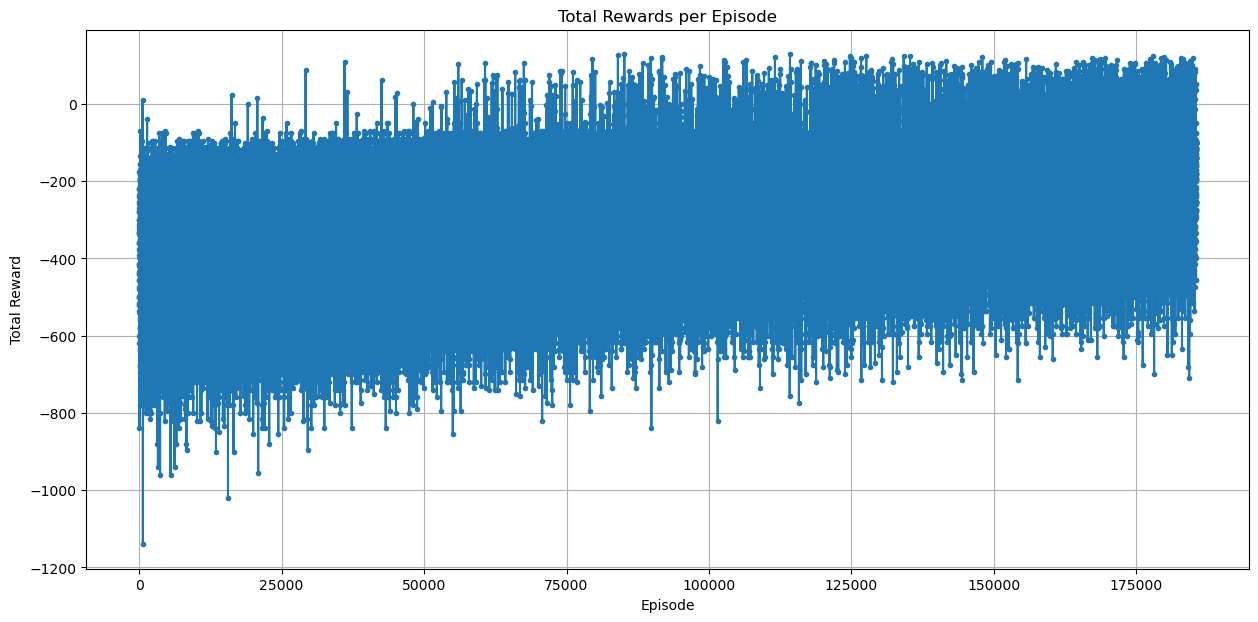

In [2508]:
plt.figure(figsize=(15, 7))
plt.plot(bonus_rewards["rewards_per_episode"], marker='.')
plt.title("Total Rewards per Episode")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.show()

In [2509]:
len(bonus_rewards["rewards_per_episode"])

185501

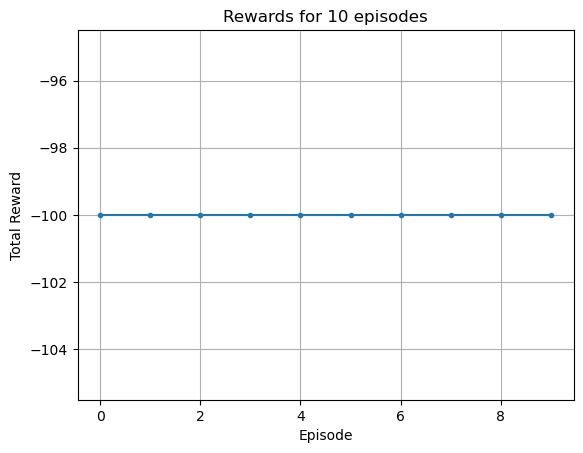

In [2510]:
episode_rewards =[] 
for episode in range(10):
    env= WarehouseRobotEnvironment('deterministic')
    obs, info = env.reset()
    terminated, truncated = False, False

    step_dir = {0: "down", 1: "up", 2: "right", 3: "left", 4: "pick-up", 5: "drop-off"}
    time_step = 1

    while not terminated:
        action = Learned_Q_Action(obs, bonus_q_table)
        obs, reward, terminated, truncated, info = env.step(action)
        time_step += 1
    episode_rewards.append(reward)

plt.plot(episode_rewards, marker='.')
plt.title("Rewards for 10 episodes")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.show()

In [2511]:
print("Performing actions based on Q-table:-\n")

for episode in range(1):
    print("Episode:", episode+1)
    obs, info = env.reset()
    terminated, truncated = False, False

    step_dir = {0: "down", 1: "up", 2: "right", 3: "left", 4: "pick-up", 5: "drop-off"}
    time_step = 1

    while not terminated:
        action = Learned_Q_Action(obs, bonus_q_table)
        obs, reward, terminated, truncated, info = env.step(action)
        print(f"Action: {action:<2} {str('(') + step_dir[action] + str(')'):<11} | Reward: {reward:4} | Done: {str(terminated):<5} | Timestep: {time_step:<2}")
        # env.render()
        time_step += 1

Performing actions based on Q-table:-

Episode: 1
Action: 5  (drop-off)  | Reward:   -1 | Done: False | Timestep: 1 
Action: 5  (drop-off)  | Reward:   -2 | Done: False | Timestep: 2 
Action: 5  (drop-off)  | Reward:   -3 | Done: False | Timestep: 3 
Action: 5  (drop-off)  | Reward:   -4 | Done: False | Timestep: 4 
Action: 5  (drop-off)  | Reward:   -5 | Done: False | Timestep: 5 
Action: 5  (drop-off)  | Reward:   -6 | Done: False | Timestep: 6 
Action: 5  (drop-off)  | Reward:   -7 | Done: False | Timestep: 7 
Action: 5  (drop-off)  | Reward:   -8 | Done: False | Timestep: 8 
Action: 5  (drop-off)  | Reward:   -9 | Done: False | Timestep: 9 
Action: 5  (drop-off)  | Reward:  -10 | Done: False | Timestep: 10
Action: 5  (drop-off)  | Reward:  -11 | Done: False | Timestep: 11
Action: 5  (drop-off)  | Reward:  -12 | Done: False | Timestep: 12
Action: 5  (drop-off)  | Reward:  -13 | Done: False | Timestep: 13
Action: 5  (drop-off)  | Reward:  -14 | Done: False | Timestep: 14
Action: 5  (

In [2512]:
len(bonus_q_table)

186624

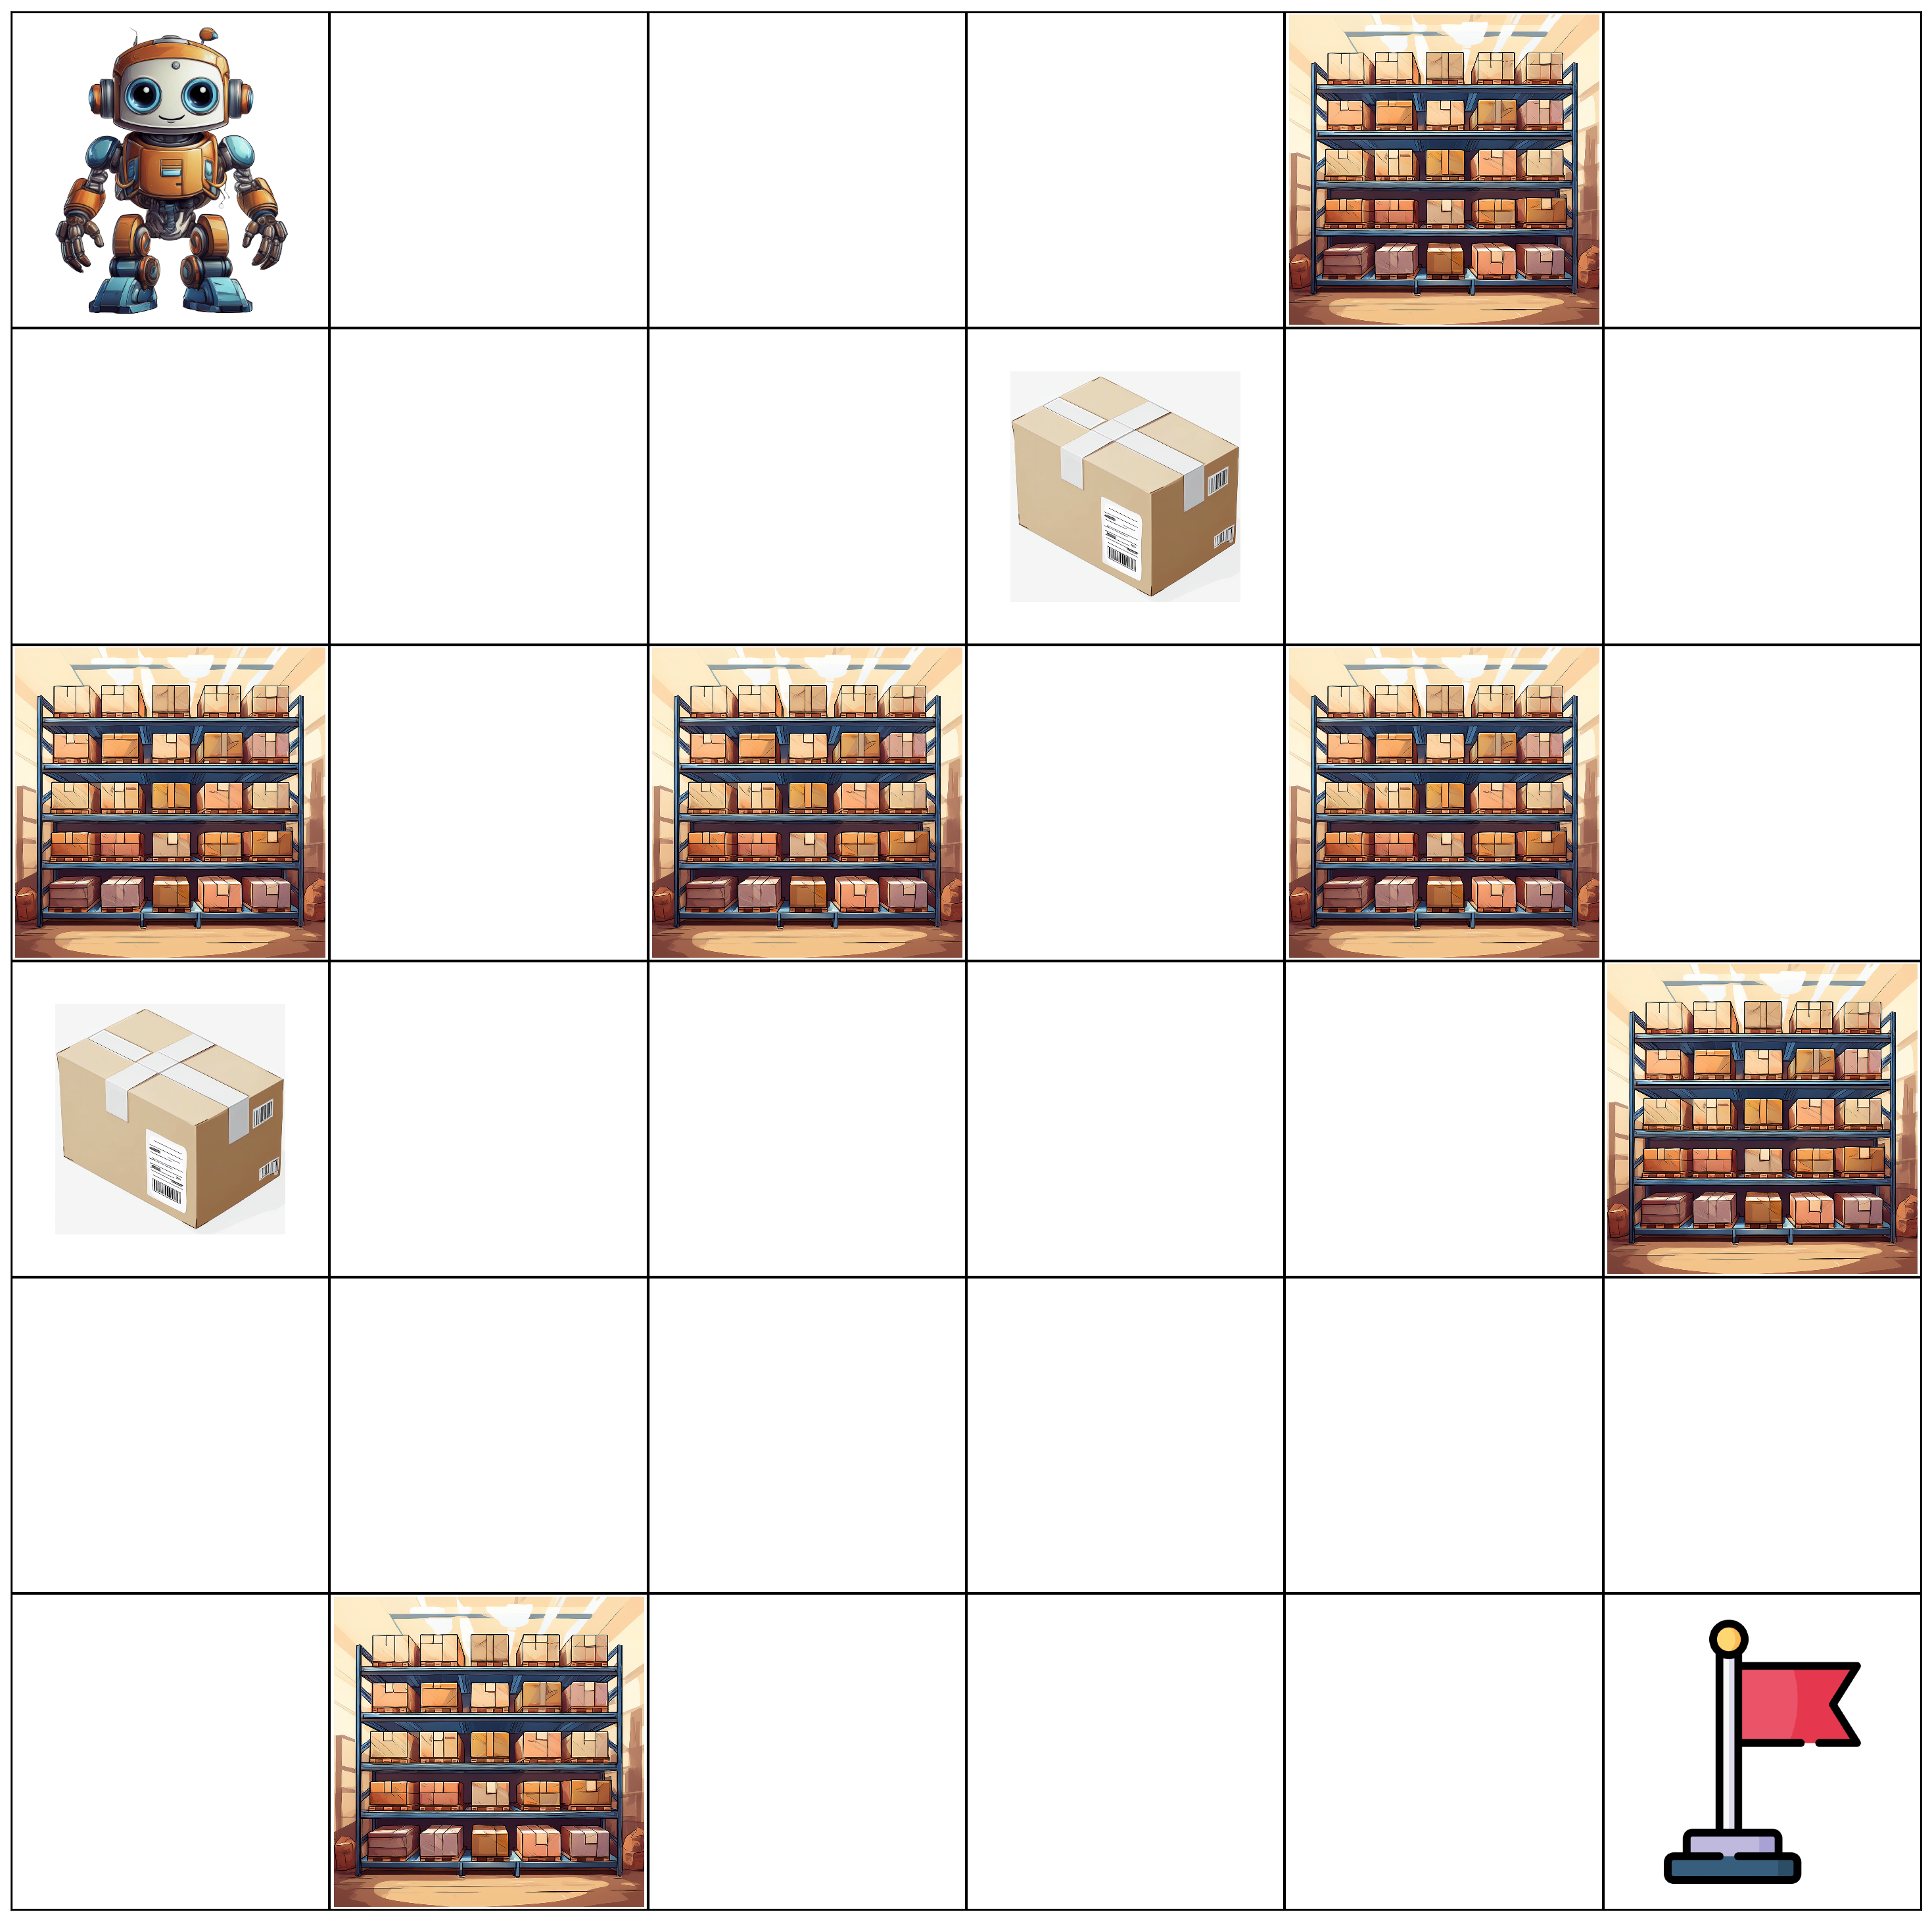

In [2513]:
env.render(plot=True)

In [2514]:
episodes = 1000000
epsilon = 1
dg = 0.999996
min_epsilon=0.01
for episode in range(episodes+1):
    if episode in [int(0.1*i*episodes) for i in range(1,11)]:
        print(episode,"/",episodes, " Epsilon:", epsilon)
    epsilon = max(min_epsilon, epsilon * dg) 

100000 / 1000000  Epsilon: 0.6703195097781303
200000 / 1000000  Epsilon: 0.4493282451891867
300000 / 1000000  Epsilon: 0.3011934890446803
400000 / 1000000  Epsilon: 0.2018958719247935
500000 / 1000000  Epsilon: 0.13533474189485395
600000 / 1000000  Epsilon: 0.09071751784290885
700000 / 1000000  Epsilon: 0.06080972208874552
800000 / 1000000  Epsilon: 0.040761943100271876
900000 / 1000000  Epsilon: 0.027323525716579037
1000000 / 1000000  Epsilon: 0.018315492363746817
